# Flood AutoML — Deteksi Anomali Cuaca untuk Estimasi Probabilitas Banjir
**Balikpapan & Samarinda** · Random Forest · XGBoost · CatBoost · Isolation Forest

Mengikuti alur pada jurnal, saya menggabungkan catatan kejadian banjir BNPB dengan data cuaca harian
Open-Meteo, mengubahnya menjadi fitur *time-series* (lag t-1..t-7 dan akumulasi 3/7/14 hari),
menambahkan skor anomali dari **Isolation Forest**, lalu melatih tiga algoritma *tree-ensemble* di
dalam kerangka **AutoML** untuk memprediksi probabilitas banjir tiga hari ke depan (`Flood_next_3d`).

## 0. Meng-clone repository (Google Colab)

Saat dijalankan di Colab, saya meng-clone repository agar dataset dan skrip pendukung ikut tersedia,
lalu berpindah ke direktori repo sebagai direktori kerja.

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/Noelsip/flood-bpn-smd.git"

def in_colab():
    return "google.colab" in sys.modules

if in_colab():
    repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(repo_dir)
    print("Repo di-clone. Direktori kerja:", os.getcwd())
else:
    print("Bukan Colab: memakai file repo lokal.")

Repo di-clone. Direktori kerja: /content/flood-bpn-smd


## 1. Memasang dependensi

In [2]:
import importlib

REQUIRED = ["numpy", "pandas", "scikit-learn", "xgboost", "catboost", "flaml[automl]", "matplotlib"]

def ensure(module, pip_name=None):
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)

if in_colab():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *REQUIRED], check=True)
    print("Dependensi terpasang.")
else:
    for module, pip_name in [("flaml", "flaml[automl]"), ("xgboost", "xgboost"), ("catboost", "catboost")]:
        ensure(module, pip_name)
    print("Dependensi lokal siap.")

Dependensi terpasang.


## 2. Mengimpor library

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from flaml import AutoML

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 3. Menetapkan konfigurasi dan daftar fitur

In [4]:
SEED = 42
HORIZON = 3
TARGET = "Flood_next_3d"
ANOMALY_CONTAMINATION = 0.05
TIME_BUDGET = 120
THRESHOLD_BETA = 2.0
KALTIM_CITIES = ["Kota Balikpapan", "Kota Samarinda"]

ROOT = Path.cwd()
DATA_PATH = ROOT / "processed" / "dataset_timeseries.csv"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

WEATHER_COLS = ["precip", "tmax", "tmin", "wind", "rain", "soil"]
LAG_COLS = [f"{c}_lag{k}" for c in WEATHER_COLS for k in range(1, 8)]
ROLL_COLS = ["rain_roll3_sum", "rain_roll7_sum", "rain_roll14_sum",
             "precip_roll3_sum", "precip_roll7_sum",
             "soil_roll3_mean", "soil_roll7_mean", "tmax_roll7_mean"]
PCTL_COLS = ["rain7_pctl", "precip7_pctl", "soil7_pctl"]
CALENDAR_COLS = ["doy_sin", "doy_cos", "month_sin", "month_cos"]
BASE_FEATURES = LAG_COLS + ROLL_COLS + PCTL_COLS + CALENDAR_COLS

## 4. Memuat dataset *time-series* siap model

Dataset pusat sudah dibangun lewat `processed/build_timeseries_dataset.py`: setiap baris adalah satu
hari-kota dengan fitur lag, akumulasi hujan, persentil, dan kolom `split` (kronologis 70/30) sehingga
data uji hanya berisi Balikpapan & Samarinda pada periode terbaru.

In [5]:
data = pd.read_csv(DATA_PATH, parse_dates=["time"]).sort_values(["split", "time", "city"]).reset_index(drop=True)
print("Dataset:", data.shape)
print(data.groupby("split")[TARGET].agg(count="count", banjir="sum"))
data.head()

Dataset: (21570, 68)
       count  banjir
split               
test    1284      30
train  20286    1909


,city,time,precip,tmax,tmin,wind,rain,soil,Flood,doy_sin,...,precip_roll3_sum,precip_roll7_sum,soil_roll3_mean,soil_roll7_mean,tmax_roll7_mean,rain7_pctl,precip7_pctl,soil7_pctl,Flood_next_3d,split
0,Kota Samarinda,2023-08-07,1.6000,31.8000,23.5000,13.7000,1.6000,0.3400,0,-0.5794,...,7.9000,10.1000,0.3527,0.3610,32.0571,0.0229,0.0229,0.0707,0,test
1,Kota Balikpapan,2023-08-08,0.8000,29.3000,25.9000,20.0000,0.8000,0.3210,0,-0.5933,...,4.5000,12.4000,0.3277,0.3316,29.3571,0.0314,0.0314,0.0165,0,test
2,Kota Samarinda,2023-08-08,0.8000,32.0000,23.5000,13.0000,0.8000,0.3350,0,-0.5933,...,9.5000,11.5000,0.3467,0.3560,31.9429,0.0262,0.0262,0.0668,0,test
3,Kota Balikpapan,2023-08-09,1.1000,29.1000,25.5000,17.4000,1.1000,0.3170,0,-0.6071,...,4.2000,11.5000,0.3243,0.3291,29.3286,0.0276,0.0276,0.0144,0,test
4,Kota Samarinda,2023-08-09,2.1000,32.0000,23.7000,11.4000,2.1000,0.3310,0,-0.6071,...,4.4000,12.0000,0.3407,0.3510,32.0286,0.0276,0.0276,0.0648,0,test


## 5. Menelaah sebaran kelas dan pemicu hujan

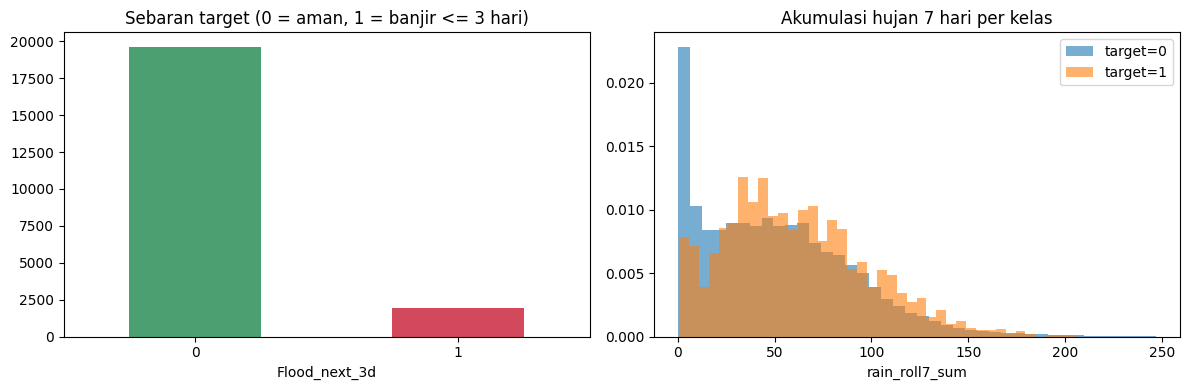

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data[TARGET].value_counts().sort_index().plot.bar(ax=ax[0], color=["#4C9F70", "#D1495B"], rot=0)
ax[0].set_title("Sebaran target (0 = aman, 1 = banjir <= 3 hari)")
ax[0].set_xlabel(TARGET)
for label, grp in data.groupby(TARGET):
    ax[1].hist(grp["rain_roll7_sum"], bins=40, alpha=0.6, density=True, label=f"target={label}")
ax[1].set_title("Akumulasi hujan 7 hari per kelas")
ax[1].set_xlabel("rain_roll7_sum"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Memisahkan data secara kronologis

Saya memakai kolom `split` bawaan dataset agar pembagian tetap kronologis dan tidak ada kebocoran
data masa depan ke dalam pelatihan.

In [7]:
train_df = data[data["split"] == "train"].reset_index(drop=True)
test_df = data[data["split"] == "test"].reset_index(drop=True)
y_train = train_df[TARGET].astype(int)
y_test = test_df[TARGET].astype(int)
print(f"Train: {train_df.shape} | banjir: {int(y_train.sum())}")
print(f"Test : {test_df.shape} | banjir: {int(y_test.sum())}")
print("Kota test:", sorted(test_df["city"].unique()))

Train: (20286, 68) | banjir: 1909
Test : (1284, 68) | banjir: 30
Kota test: ['Kota Balikpapan', 'Kota Samarinda']


## 7. Mendeteksi anomali cuaca dengan Isolation Forest

Saya melatih Isolation Forest hanya pada cuaca hari-hari normal (non-banjir) di data latih, lalu
memberi skor anomali untuk seluruh baris. Skor ini saya jadikan fitur tambahan bagi AutoML—mengikuti
gagasan jurnal bahwa kondisi cuaca yang menyimpang sering mendahului kejadian banjir.

Jumlah fitur model: 58 (termasuk anomaly_score)
Anomali pada train: 1096 | di antaranya berlabel banjir: 177


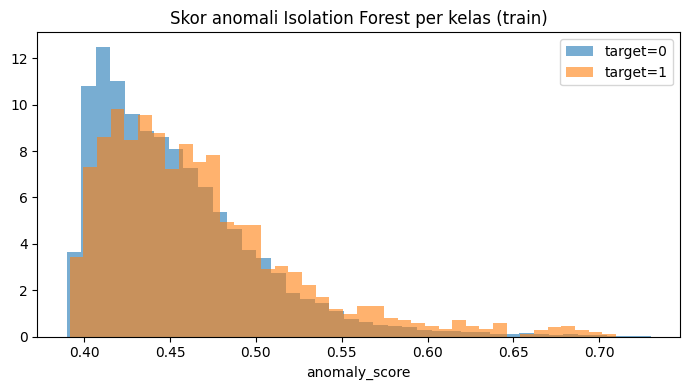

In [8]:
iso = IsolationForest(n_estimators=400, contamination=ANOMALY_CONTAMINATION, random_state=SEED, n_jobs=-1)
iso.fit(train_df.loc[y_train == 0, WEATHER_COLS])

for frame in (train_df, test_df):
    frame["anomaly_score"] = -iso.score_samples(frame[WEATHER_COLS])
    frame["is_anomaly"] = (iso.predict(frame[WEATHER_COLS]) == -1).astype(int)

FEATURES = BASE_FEATURES + ["anomaly_score"]
print("Jumlah fitur model:", len(FEATURES), "(termasuk anomaly_score)")
print("Anomali pada train:", int(train_df["is_anomaly"].sum()),
      "| di antaranya berlabel banjir:", int(train_df.loc[y_train == 1, "is_anomaly"].sum()))

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in train_df.groupby(TARGET):
    ax.hist(grp["anomaly_score"], bins=40, alpha=0.6, density=True, label=f"target={label}")
ax.set_title("Skor anomali Isolation Forest per kelas (train)")
ax.set_xlabel("anomaly_score"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Menyiapkan fitur dan menstandarkan skala

Saya mengepas `StandardScaler` hanya pada data latih lalu menerapkannya ke data uji agar statistik
penskalaan tidak bocor dari masa depan.

In [9]:
scaler = StandardScaler().fit(train_df[FEATURES])
X_train = pd.DataFrame(scaler.transform(train_df[FEATURES]), columns=FEATURES)
X_test = pd.DataFrame(scaler.transform(test_df[FEATURES]), columns=FEATURES)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (20286, 58) | X_test: (1284, 58)


## 9. Menangani ketidakseimbangan kelas

Banjir adalah kelas minoritas, jadi saya menghitung `scale_pos_weight` dari data latih dan
memberikannya sebagai bobot kelas—pendekatan *cost-sensitive* yang menghindari kebocoran data
dibanding *resampling*.

In [10]:
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print(f"Rasio kelas train -> negatif:positif = {neg}:{pos} (scale_pos_weight={scale_pos_weight:.2f})")

Rasio kelas train -> negatif:positif = 18377:1909 (scale_pos_weight=9.63)


## 10. Melatih tiga model dan mencari arsitektur lewat AutoML

Saya melatih Random Forest, XGBoost, dan CatBoost dengan pembobotan kelas, lalu membiarkan FLAML
mencari kombinasi estimator dan hyperparameter terbaik di antara ketiganya dengan metrik AUC-PR (`ap`).

In [11]:
def fit_models(X, y, spw):
    fitted = {}
    fitted["Random Forest"] = RandomForestClassifier(
        n_estimators=400, random_state=SEED, n_jobs=-1, class_weight="balanced_subsample").fit(X, y)
    fitted["XGBoost"] = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=3.0, min_child_weight=3, eval_metric="logloss", scale_pos_weight=spw,
        random_state=SEED, n_jobs=-1).fit(X, y)
    fitted["CatBoost"] = CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05, class_weights=[1.0, spw],
        random_seed=SEED, verbose=0, allow_writing_files=False).fit(X, y)

    automl = AutoML()
    automl.fit(X_train=X, y_train=y, task="classification", metric="ap",
               estimator_list=["rf", "xgboost", "catboost"], time_budget=TIME_BUDGET,
               eval_method="cv", n_splits=5, seed=SEED, verbose=1)
    fitted["AutoML (FLAML)"] = automl
    return fitted, automl

models, automl = fit_models(X_train, y_train, scale_pos_weight)
print("Estimator AutoML terbaik:", automl.best_estimator)
print("Konfigurasi terbaik:", automl.best_config)

Estimator AutoML terbaik: xgboost
Konfigurasi terbaik: {'n_estimators': 28, 'max_leaves': 40, 'min_child_weight': np.float64(2.813215490033363), 'learning_rate': np.float64(0.17833729167608375), 'subsample': np.float64(0.8676989550761623), 'colsample_bylevel': np.float64(0.9761142820940875), 'colsample_bytree': np.float64(0.9763763639565334), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(6.40085221135825)}


## 11. Mengevaluasi seluruh model pada data uji

Saya membandingkan keluaran tiap model dengan accuracy, precision, recall, F1, AUC-ROC, dan AUC-PR.
Isolation Forest ikut disertakan sebagai *baseline* tak-terawasi: skornya untuk kurva, flag
`is_anomaly` untuk prediksi kelasnya.

In [12]:
def proba(model, X):
    return np.asarray(model.predict_proba(X))[:, 1]

scores = {name: proba(m, X_test) for name, m in models.items()}
scores["Isolation Forest"] = test_df["anomaly_score"].to_numpy()

rows = []
for name, p in scores.items():
    pred = test_df["is_anomaly"].to_numpy() if name == "Isolation Forest" else (p >= 0.5).astype(int)
    rows.append(dict(Model=name,
                     Accuracy=accuracy_score(y_test, pred),
                     Precision=precision_score(y_test, pred, zero_division=0),
                     Recall=recall_score(y_test, pred, zero_division=0),
                     F1=f1_score(y_test, pred, zero_division=0),
                     AUC_ROC=roc_auc_score(y_test, p),
                     AUC_PR=average_precision_score(y_test, p)))
comparison = pd.DataFrame(rows).set_index("Model").sort_values("AUC_PR", ascending=False)
comparison.to_csv(OUT_DIR / "model_comparison.csv")
comparison

,Accuracy,Precision,Recall,F1,AUC_ROC,AUC_PR
Model,,,,,,
Isolation Forest,0.9408,0.0577,0.1000,0.0732,0.5183,0.0768
CatBoost,0.9502,0.0750,0.1000,0.0857,0.4913,0.0511
AutoML (FLAML),0.9766,0.0000,0.0000,0.0000,0.5201,0.0496
XGBoost,0.8863,0.0246,0.1000,0.0395,0.5107,0.0342
Random Forest,0.9766,0.0000,0.0000,0.0000,0.5192,0.0316


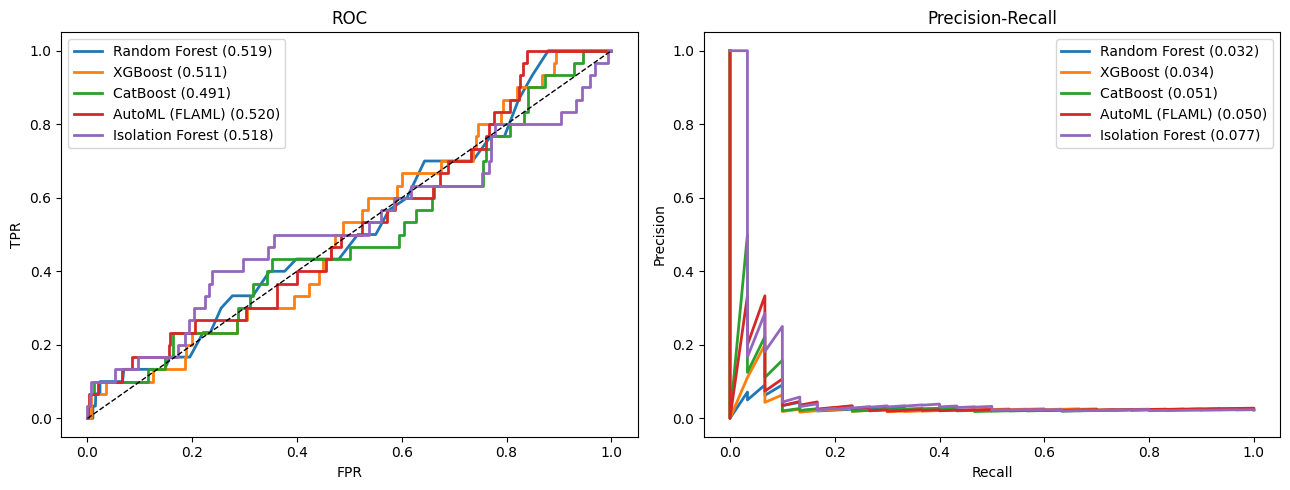

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, p in scores.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, lw=2, label=f"{name} ({roc_auc_score(y_test, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rc, pr, lw=2, label=f"{name} ({average_precision_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 12. Memilih ambang operasional yang mengutamakan recall

Saya memilih ambang dari prediksi model AutoML pada data latih dengan memaksimalkan F-beta (beta=2)
agar lebih sensitif menangkap kejadian banjir, lalu menerapkannya ke data uji.

In [14]:
best_name = "AutoML (FLAML)"
best_model = models[best_name]
p_train = proba(best_model, X_train)
beta2 = THRESHOLD_BETA ** 2

candidates = np.unique(np.r_[np.linspace(0.05, 0.95, 181), p_train])
grid = []
for thr in candidates:
    pred = (p_train >= thr).astype(int)
    prec = precision_score(y_train, pred, zero_division=0)
    rec = recall_score(y_train, pred, zero_division=0)
    fbeta = (1 + beta2) * prec * rec / (beta2 * prec + rec + 1e-12)
    grid.append((thr, prec, rec, fbeta))
thr_df = pd.DataFrame(grid, columns=["thr", "precision", "recall", "fbeta"])
OPER_THR = float(thr_df.sort_values(["fbeta", "recall"], ascending=False).iloc[0]["thr"])
print(f"Ambang operasional terpilih (F-beta={THRESHOLD_BETA}, utamakan recall): {OPER_THR:.3f}")

Ambang operasional terpilih (F-beta=2.0, utamakan recall): 0.166


## 13. Mengukur kinerja akhir pada data uji

Model operasional: AutoML (FLAML) (AutoML -> xgboost)
              precision    recall  f1-score   support

        Aman       0.98      0.98      0.98      1254
      Banjir       0.09      0.10      0.10        30

    accuracy                           0.96      1284
   macro avg       0.53      0.54      0.54      1284
weighted avg       0.96      0.96      0.96      1284

AUC-ROC = 0.520 | AUC-PR = 0.050


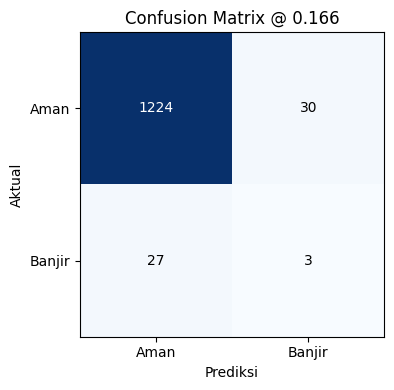

In [15]:
p_test = proba(best_model, X_test)
pred_test = (p_test >= OPER_THR).astype(int)
print(f"Model operasional: {best_name} (AutoML -> {automl.best_estimator})")
print(classification_report(y_test, pred_test, target_names=["Aman", "Banjir"], zero_division=0))
print(f"AUC-ROC = {roc_auc_score(y_test, p_test):.3f} | AUC-PR = {average_precision_score(y_test, p_test):.3f}")

cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Aman", "Banjir"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Aman", "Banjir"])
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix @ {OPER_THR:.3f}")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

## 14. Menelaah kepentingan fitur dan menyimpan hasil

Saya merata-ratakan kepentingan fitur dari ketiga model untuk melihat apakah `anomaly_score` dan
akumulasi hujan benar-benar berkontribusi, lalu menyimpan perbandingan model dan prediksi akhir.

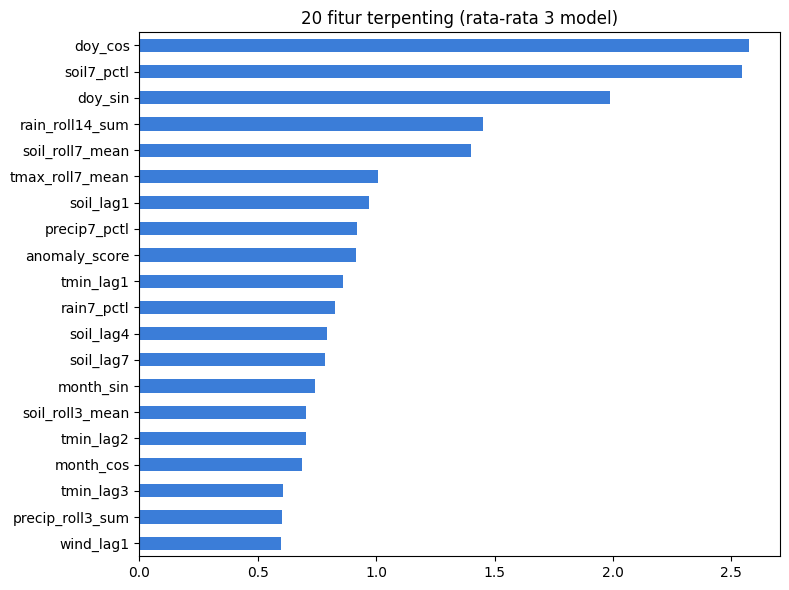

Disimpan: /content/flood-bpn-smd/outputs/model_comparison.csv
Disimpan: /content/flood-bpn-smd/outputs/feature_importance.csv
Disimpan: /content/flood-bpn-smd/outputs/flood_predictions.csv


,city,time,Flood_next_3d,flood_proba,anomaly_score,alert
0,Kota Samarinda,2023-08-07,0,0.0354,0.4043,0
1,Kota Balikpapan,2023-08-08,0,0.0123,0.4874,0
2,Kota Samarinda,2023-08-08,0,0.0260,0.4007,0
3,Kota Balikpapan,2023-08-09,0,0.0130,0.4636,0
4,Kota Samarinda,2023-08-09,0,0.0460,0.4060,0


In [16]:
importances = {
    "Random Forest": pd.Series(models["Random Forest"].feature_importances_, index=FEATURES),
    "XGBoost": pd.Series(models["XGBoost"].feature_importances_, index=FEATURES),
    "CatBoost": pd.Series(models["CatBoost"].feature_importances_, index=FEATURES),
}
imp_df = pd.DataFrame(importances)
imp_df["mean"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp_df["mean"].head(20).iloc[::-1].plot.barh(ax=ax, color="#3B7DD8")
ax.set_title("20 fitur terpenting (rata-rata 3 model)")
plt.tight_layout(); plt.show()

imp_df.to_csv(OUT_DIR / "feature_importance.csv")

predictions = test_df[["city", "time", TARGET]].copy()
predictions["flood_proba"] = p_test
predictions["anomaly_score"] = test_df["anomaly_score"].to_numpy()
predictions["alert"] = pred_test
predictions.to_csv(OUT_DIR / "flood_predictions.csv", index=False)

for name in ["model_comparison.csv", "feature_importance.csv", "flood_predictions.csv"]:
    print("Disimpan:", OUT_DIR / name)
predictions.head()